In [2]:
from tqdm import tqdm

import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Subset

from torchvision.datasets import CIFAR10
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

from IPython.display import clear_output
import matplotlib.pyplot as plt

# Чтение и подготовка данных

Для начала обозначим преобразования для данных. Нам нужно превратить картинки в тензоры, для этого есть ToTensor(), а также нормализовать данные от 0 до 1 (значения от 0 до 255 имеют большой скейл и нейронки хуже будут с ними работать)

In [3]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

# Normalize shifts scale values to 0 area (mean) and scale to 1 (square)

# Calculating as mean of (Red, Green, Blue)
#                std of (Red, Green, Blue)

Теперь создадим готовый датасет из PyTorch и загрузчик данных для создания батчей

In [4]:
train_dataset = CIFAR10(root='cifar10', train=True, download=True, transform=transform)

100%|██████████| 170M/170M [00:02<00:00, 77.7MB/s] 


In [5]:
print(train_dataset[0][0].shape)

torch.Size([3, 32, 32])


Давайте посмотрим, что возвращает датасет и даталоадер

In [6]:
train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True)

Посмотрим как выглядит семпл

In [7]:
batch = next(iter(train_loader))
batch[0].shape

torch.Size([8, 3, 32, 32])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.1308641].


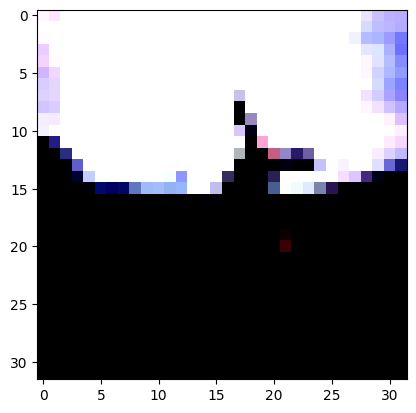

In [8]:
sample_img = batch[0].numpy()[1].transpose(1, 2, 0)

plt.imshow(sample_img)

# Простая CNN

Давайте сделаем простую CNN. Сделаем ее с 3 свертками и пулингом

In [9]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(1024, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 4 * 4)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

Посмотрим, что она выдаст

In [10]:
cnn = BasicCNN()

out = cnn(batch[0])
print(out.shape)

torch.Size([8, 10])


# Напишем код для тренировки

Тренировка и тестирование будет реализованно в классе Trainer

Обозначим конфиг, где будут параметры для тренировки

In [17]:
config = {
    'num_epochs': 10,
    'lr': 0.01,
    'batch_size': 128,
    'test_size': 0.2,
    'debug_batches': None,
}

In [18]:
class Trainer:
    def __init__(self, model, config, transform=None):
        self.config = config
        self.transform = transform

        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.model = model.to(self.device)

        self.optimizer = Adam(self.model.parameters(), lr=self.config['lr'])
        self.scheduler = StepLR(self.optimizer, step_size=5, gamma=0.1)
        self.loss_function = nn.CrossEntropyLoss()

        self.history = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
            'val_precision': [],
            'val_recall': [],
            'val_f1': []
        }

        self.setup_dataloaders()

    def setup_dataloaders(self):
        train_dataset_full = CIFAR10(root='cifar10', train=True, download=True, transform=self.transform)
        test_dataset = CIFAR10(root='cifar10', train=False, download=True, transform=self.transform)

        train_indices, val_indices = train_test_split(list(range(len(train_dataset_full))), test_size=self.config['test_size'], random_state=42, shuffle=True)
        train_dataset = Subset(train_dataset_full, train_indices)
        val_dataset = Subset(train_dataset_full, val_indices)

        self.train_loader = DataLoader(dataset=train_dataset, batch_size=self.config['batch_size'], shuffle=True)
        self.val_loader = DataLoader(dataset=val_dataset, batch_size=self.config['batch_size'], shuffle=False)
        self.test_loader = DataLoader(dataset=test_dataset, batch_size=self.config['batch_size'], shuffle=False)

    def plot_history(self):
        clear_output(wait=True)
    
        epochs = range(1, len(self.history['train_loss']) + 1)
    
        plt.figure(figsize=(15, 10))
    
        plt.subplot(2, 2, 1)
        plt.plot(epochs, self.history['train_loss'], label='Train Loss')
        plt.plot(epochs, self.history['val_loss'], label='Val Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Loss')
        plt.legend()
        plt.grid(True)
    
        plt.subplot(2, 2, 2)
        plt.plot(epochs, self.history['train_acc'], label='Train Accuracy')
        plt.plot(epochs, self.history['val_acc'], label='Val Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy (%)')
        plt.title('Accuracy')
        plt.legend()
        plt.grid(True)
    
        plt.subplot(2, 2, 3)
        plt.plot(epochs, self.history['val_precision'], label='Val Precision')
        plt.plot(epochs, self.history['val_recall'], label='Val Recall')
        plt.xlabel('Epoch')
        plt.ylabel('Score')
        plt.title('Precision / Recall')
        plt.legend()
        plt.grid(True)
    
        plt.subplot(2, 2, 4)
        plt.plot(epochs, self.history['val_f1'], label='Val F1')
        plt.xlabel('Epoch')
        plt.ylabel('Score')
        plt.title('F1-score')
        plt.legend()
        plt.grid(True)
    
        plt.tight_layout()
        plt.show()

    def run(self):
        for epoch in range(self.config['num_epochs']):
            train_loss, train_acc = self.train_step()
            val_loss, val_acc, val_precision, val_recall, val_f1 = self.val_step()
    
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            self.history['val_precision'].append(val_precision)
            self.history['val_recall'].append(val_recall)
            self.history['val_f1'].append(val_f1)
    
            print(
                f"Epoch {epoch + 1}/{self.config['num_epochs']}: "
                f"train_loss={train_loss:.4f}, train_acc={train_acc:.2f}% | "
                f"val_loss={val_loss:.4f}, val_acc={val_acc:.2f}% | "
                f"precision={val_precision:.4f}, recall={val_recall:.4f}, f1={val_f1:.4f}"
            )
    
            self.plot_history()

        test_loss, test_acc = self.test_step()
        print(f"Test loss: {test_loss:.4f}, test acc: {test_acc:.2f}%")

    def train_step(self):
        self.model.train()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for batch_idx, (images, labels) in enumerate(tqdm(self.train_loader)):
            if config.get('debug_batches') is not None and batch_idx >= config.get('debug_batches'):
                break
                
            images, labels = images.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()

            outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            loss.backward()

            self.optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        self.scheduler.step()

        total_loss = total_loss / len(self.train_loader)
        train_acc = correct / total_samples * 100

        return total_loss, train_acc

    def val_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        all_labels = []
        all_preds = []

        for batch_idx, (images, labels) in enumerate(tqdm(self.val_loader)):
            if config.get('debug_batches') is not None and batch_idx >= config.get('debug_batches'):
                break
                
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
                loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

        total_loss = total_loss / len(self.val_loader)
        val_acc = correct / total_samples * 100

        val_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
        val_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
        val_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

        return total_loss, val_acc, val_precision, val_recall, val_f1

    def test_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        all_labels = []
        all_preds = []

        for batch_idx, (images, labels) in enumerate(tqdm(self.test_loader)):
            if config.get('debug_batches') is not None and batch_idx >= config.get('debug_batches'):
                break
                
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
                loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

        total_loss = total_loss / len(self.test_loader)
        test_acc = correct / total_samples * 100

        class_names = self.test_loader.dataset.classes
        print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

        return total_loss, test_acc

In [19]:
basic_cnn = BasicCNN()

In [20]:
trainer = Trainer(basic_cnn, config, transform=transform)

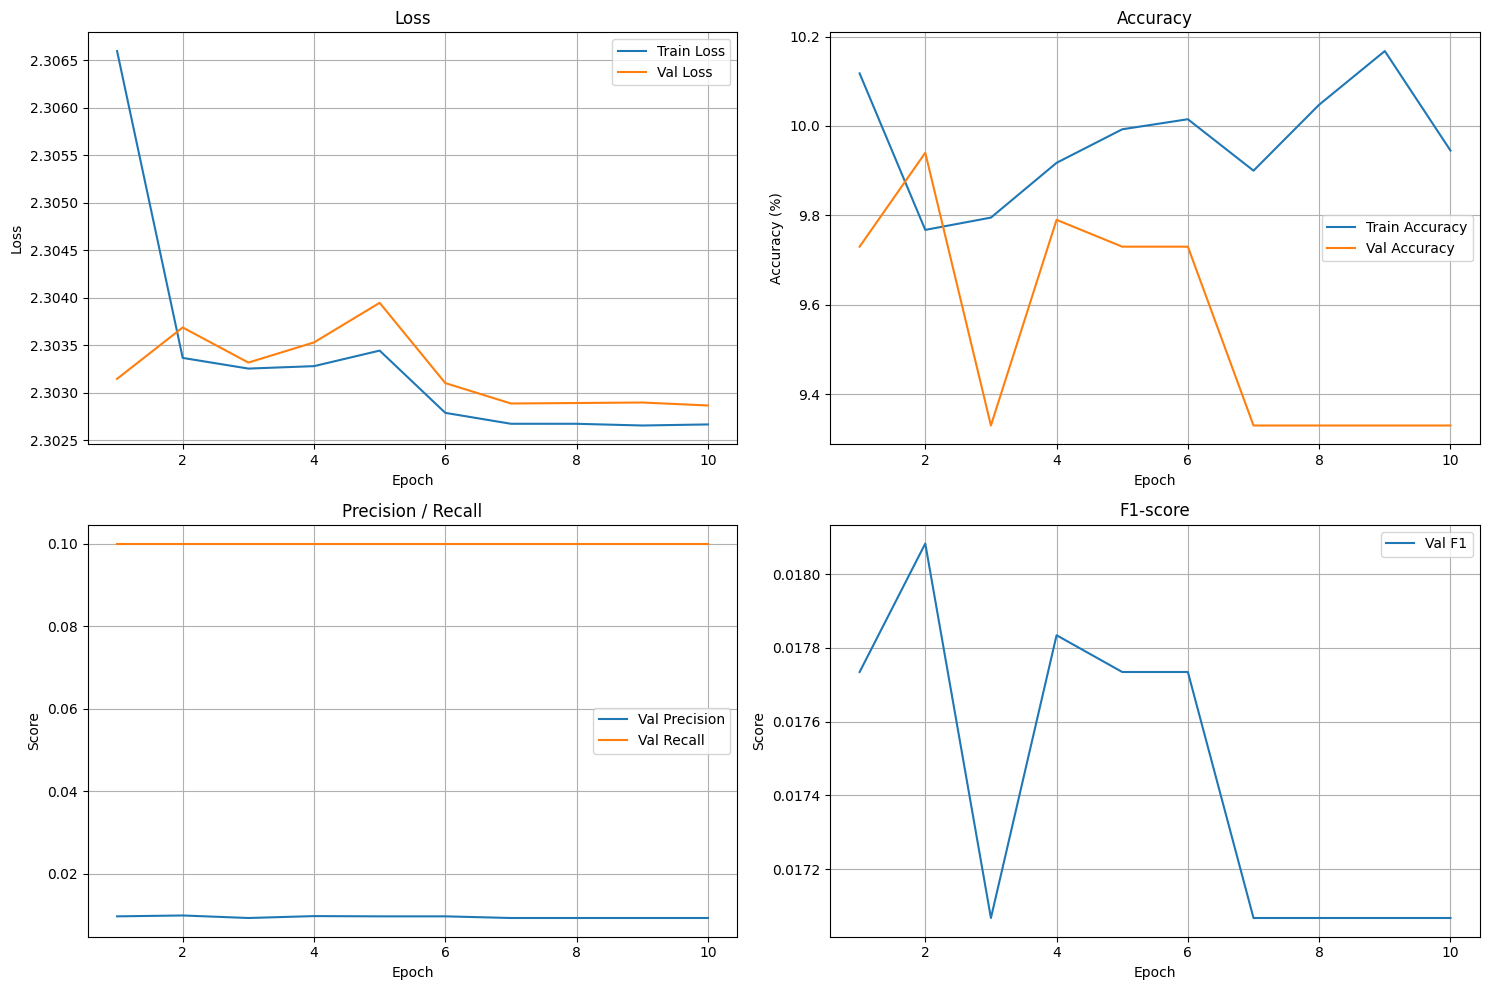

100%|██████████| 79/79 [00:02<00:00, 33.38it/s]


              precision    recall  f1-score   support

    airplane       0.00      0.00      0.00      1000
  automobile       0.00      0.00      0.00      1000
        bird       0.00      0.00      0.00      1000
         cat       0.00      0.00      0.00      1000
        deer       0.10      1.00      0.18      1000
         dog       0.00      0.00      0.00      1000
        frog       0.00      0.00      0.00      1000
       horse       0.00      0.00      0.00      1000
        ship       0.00      0.00      0.00      1000
       truck       0.00      0.00      0.00      1000

    accuracy                           0.10     10000
   macro avg       0.01      0.10      0.02     10000
weighted avg       0.01      0.10      0.02     10000

Test loss: 2.3026, test acc: 10.00%


In [21]:
trainer.run()

!!!Почему то выучил один класс deer, recall=1.00

In [59]:
lower_lr_config = {
    'num_epochs': 10,
    'lr': 0.001,
    'batch_size': 128,
    'test_size': 0.2,
    'debug_batches': None,
}

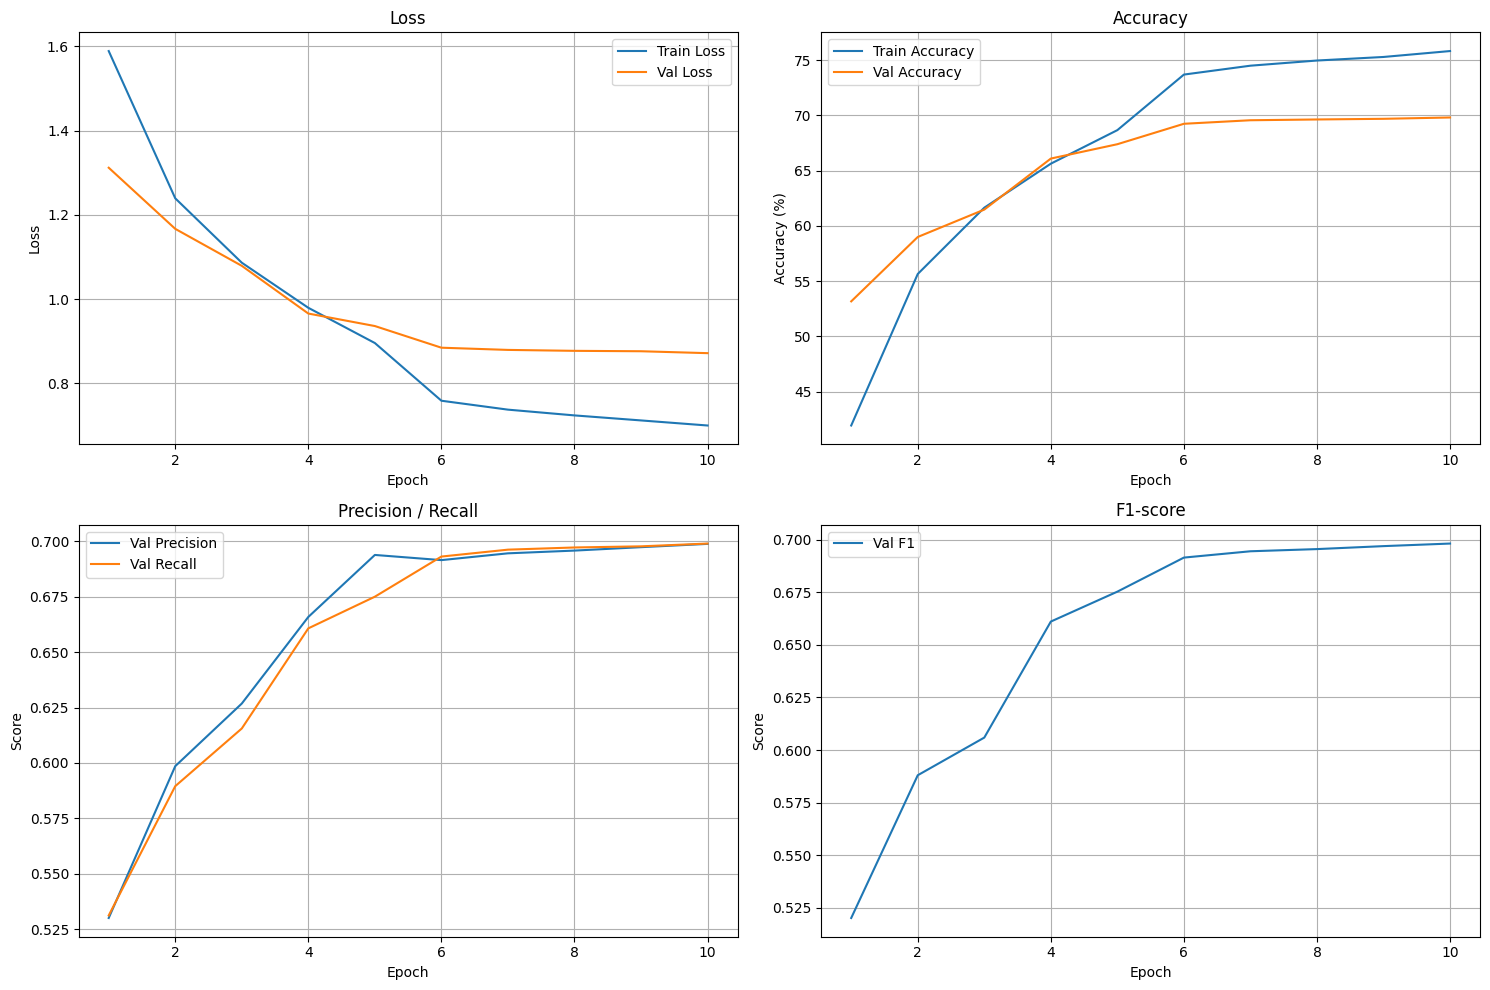

100%|██████████| 79/79 [00:02<00:00, 34.04it/s]

              precision    recall  f1-score   support

    airplane       0.74      0.75      0.75      1000
  automobile       0.83      0.80      0.82      1000
        bird       0.58      0.58      0.58      1000
         cat       0.51      0.49      0.50      1000
        deer       0.61      0.64      0.62      1000
         dog       0.61      0.59      0.60      1000
        frog       0.79      0.75      0.77      1000
       horse       0.72      0.76      0.74      1000
        ship       0.78      0.84      0.81      1000
       truck       0.79      0.76      0.77      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000

Test loss: 0.8849, test acc: 69.68%


In [60]:
basic_cnn = BasicCNN()
trainer = Trainer(basic_cnn, lower_lr_config, transform=transform)
trainer.run()

!!!Дело в lr поставил на порядок меньше и всё заработало 0.01 -> 0.001

In [61]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BasicCNNWithBatchNorm(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x)))) 
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  
        x = self.pool(F.relu(self.bn3(self.conv3(x)))) 

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [64]:
norm_basic_cnn_config = {
    'num_epochs': 10,
    'lr': 0.001,
    'batch_size': 128,
    'test_size': 0.2,
    'debug_batches': None,
}

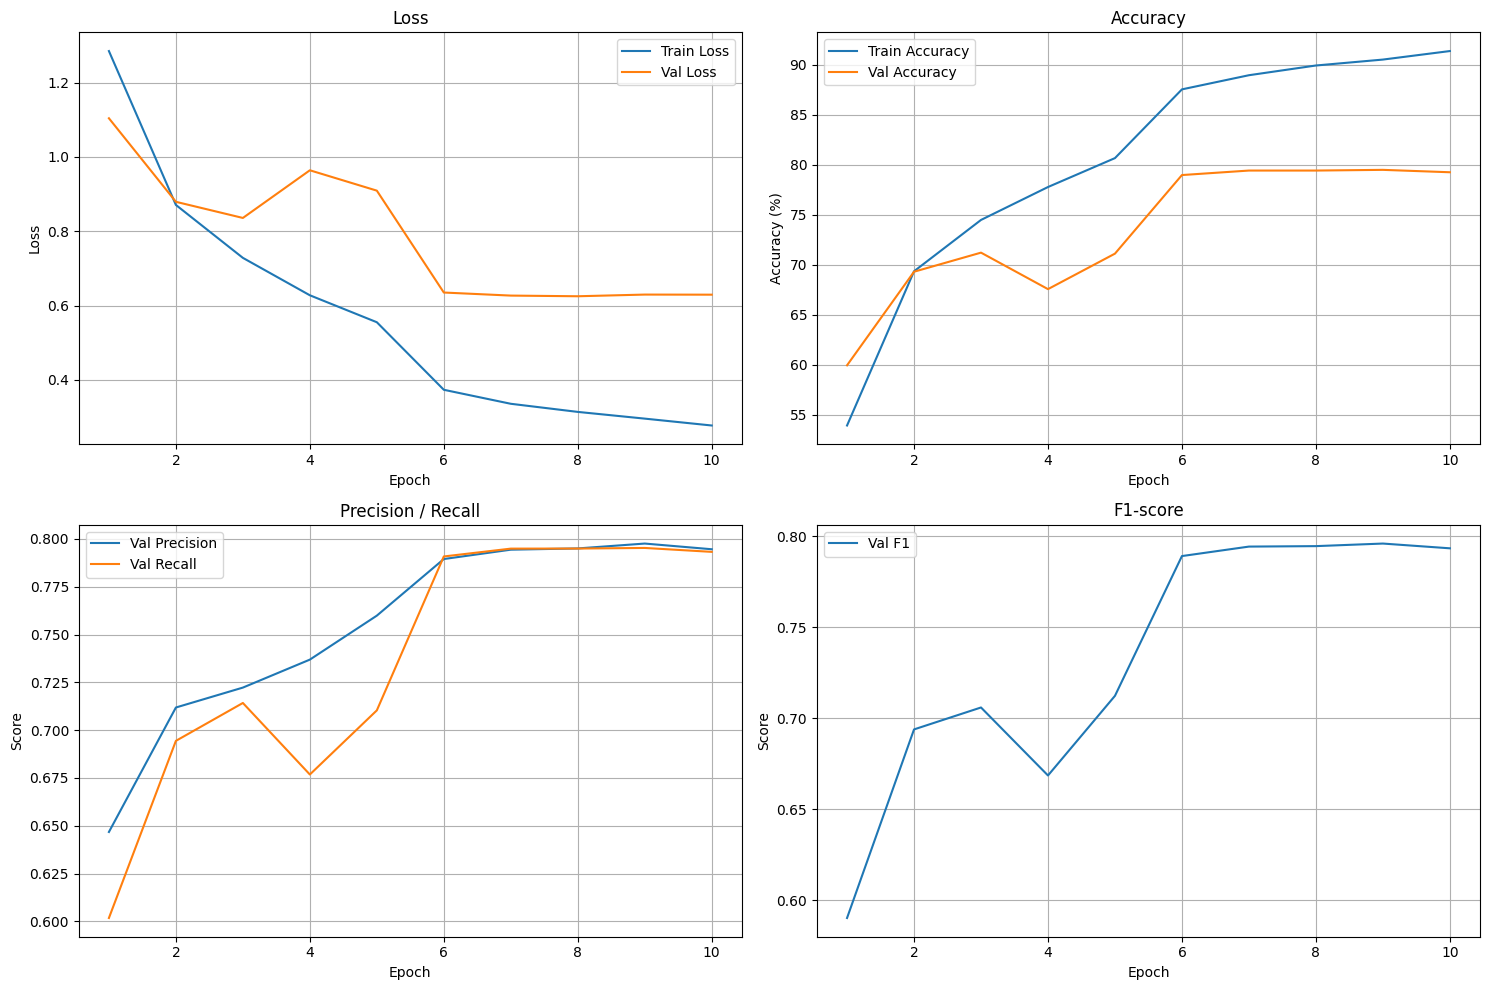

100%|██████████| 79/79 [00:02<00:00, 32.45it/s]


              precision    recall  f1-score   support

    airplane       0.80      0.82      0.81      1000
  automobile       0.89      0.86      0.87      1000
        bird       0.72      0.69      0.70      1000
         cat       0.63      0.63      0.63      1000
        deer       0.73      0.82      0.77      1000
         dog       0.70      0.69      0.70      1000
        frog       0.85      0.85      0.85      1000
       horse       0.86      0.81      0.84      1000
        ship       0.88      0.88      0.88      1000
       truck       0.85      0.85      0.85      1000

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.79      0.79      0.79     10000

Test loss: 0.6430, test acc: 78.98%


In [65]:
basic_cnn = BasicCNNWithBatchNorm()
trainer = Trainer(basic_cnn, norm_basic_cnn_config, transform=transform)
trainer.run()

In [66]:
class BasicCNNWithMoreParams(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        # self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        # self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        # self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [67]:
norm_basic_cnn_config = {
    'num_epochs': 10,
    'lr': 0.001,
    'batch_size': 128,
    'test_size': 0.2,
    'debug_batches': None,
}

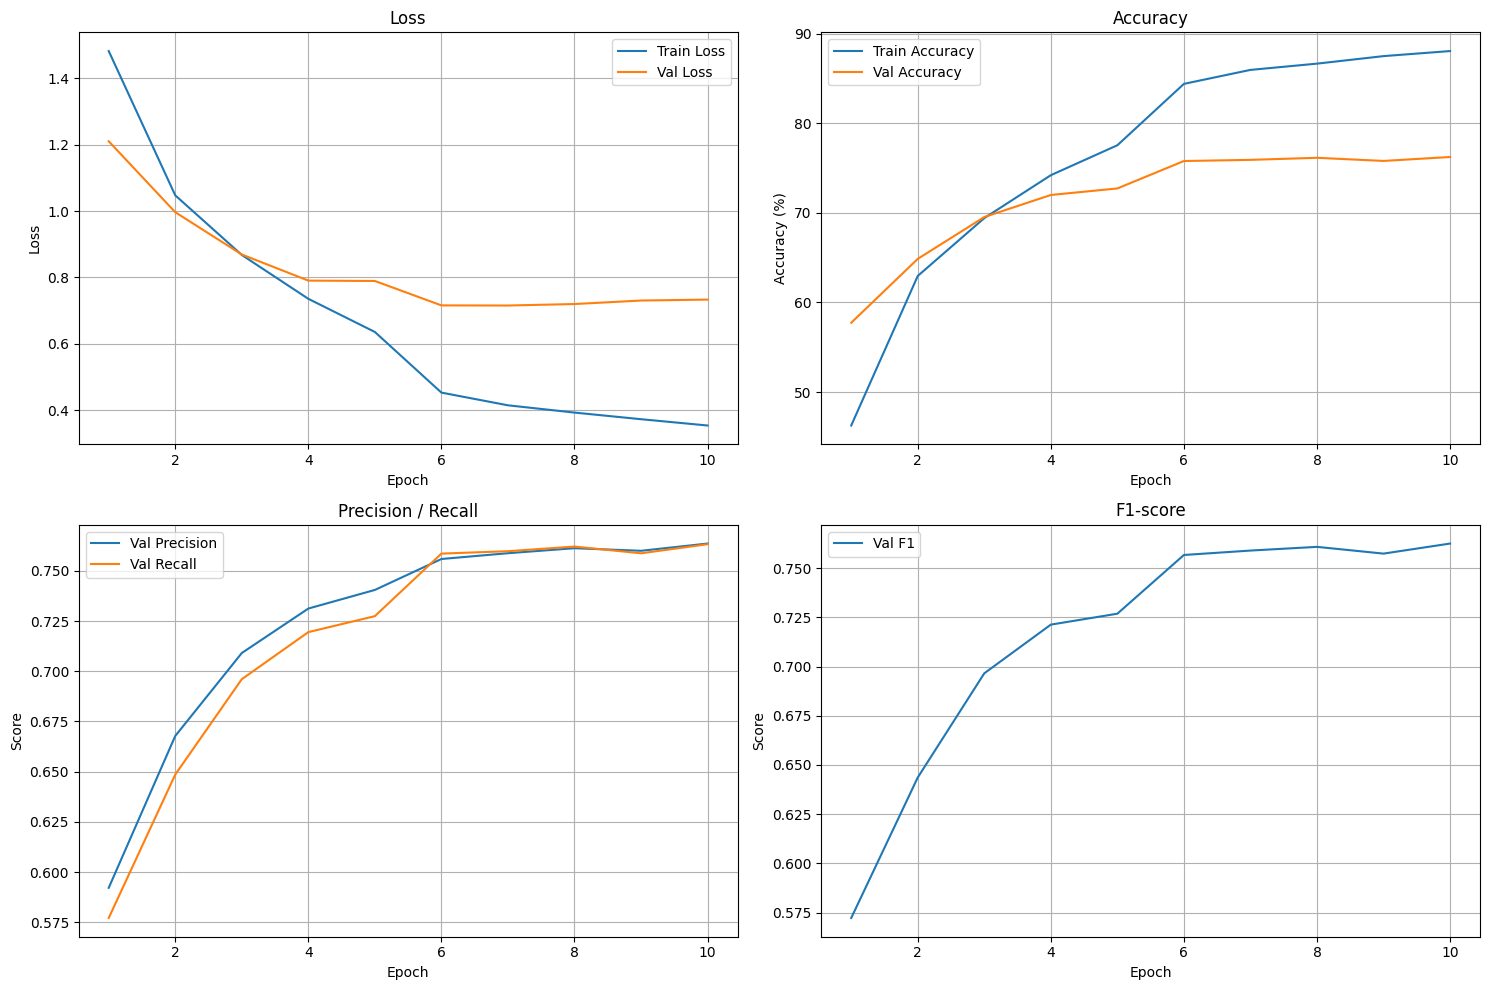

100%|██████████| 79/79 [00:02<00:00, 32.82it/s]


              precision    recall  f1-score   support

    airplane       0.74      0.84      0.79      1000
  automobile       0.85      0.87      0.86      1000
        bird       0.71      0.62      0.66      1000
         cat       0.55      0.58      0.57      1000
        deer       0.68      0.75      0.71      1000
         dog       0.68      0.65      0.67      1000
        frog       0.83      0.79      0.81      1000
       horse       0.80      0.79      0.80      1000
        ship       0.86      0.85      0.85      1000
       truck       0.87      0.80      0.83      1000

    accuracy                           0.75     10000
   macro avg       0.76      0.75      0.75     10000
weighted avg       0.76      0.75      0.75     10000

Test loss: 0.7613, test acc: 75.45%


In [68]:
basic_cnn = BasicCNNWithMoreParams()
trainer = Trainer(basic_cnn, norm_basic_cnn_config, transform=transform)
trainer.run()

# ResNet-18

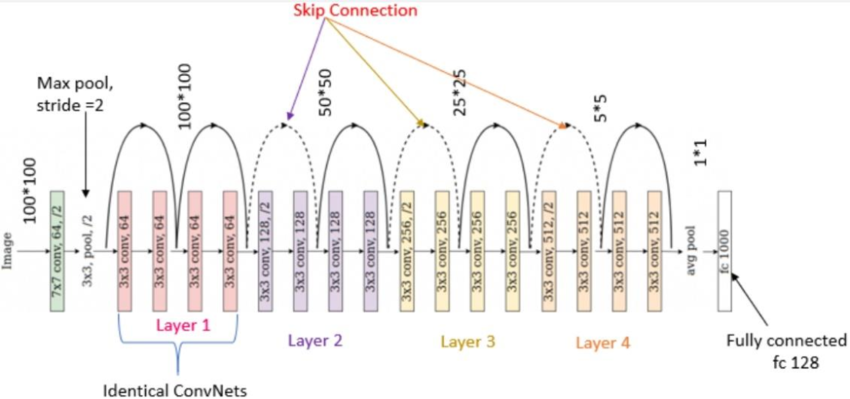

In [22]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None, activation=nn.Identity()):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample
        self.activation = activation

    def forward(self, x):
        # identity function f(x) = x
        identity = x

        if self.downsample is not None:
            identity = self.downsample(identity)

        # Применить свертки + skip connection

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.activation(out)
        
        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.activation(out)

        return out

In [23]:
class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 64

        # center of cernel 1 borders 3 there fore padding 3
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        self.max_pool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Сделать 4 блока
        self.layer1 = self.make_layer(64, blocks=2, stride=1)
        self.layer2 = self.make_layer(128, blocks=2, stride=2)
        self.layer3 = self.make_layer(256, blocks=2, stride=2)
        self.layer4 = self.make_layer(512, blocks=2, stride=2)

        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def make_layer(self, out_channels, blocks, stride=1):
        downsample = None

        # making mechanism for demansion matching
        # out = F(x) + x
        # in in_channels depth dim less than output so we must fitting it
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(
                    self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(out_channels),
            )

        layers = []
        
        # nn.ReLU with inplace faster thanks by changing tensor without creating new one
        layers.append(ResNetBlock(self.in_channels, out_channels, stride=stride, downsample=downsample, activation=nn.ReLU(inplace=True)))
        self.in_channels = out_channels
    
        for _ in range(1, blocks):
            layers.append(ResNetBlock(out_channels, out_channels, activation=nn.ReLU(inplace=True)))

        return nn.Sequential(*layers)

    def forward(self, x):
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        out = self.max_pool(out)

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        # make number from each filter map 
        out = self.avg_pool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)

        return out
        
        

$H_{out}=\frac{H_{in}+2P-D(K-1)-1}{S}+1$  

$W_{out}=\frac{W_{in}+2P-D(K-1)-1}{S}+1$  

Where:  
* $H_{in}$: input height
* $W_{in}$: input width
* $H_{out}$: output height
* $W_{out}$: output width
* $K$: kernel size
* $P$: padding
* $S$: stride
* $D$: dilation

In [25]:
res_net_config = {
    'num_epochs': 10,
    'lr': 0.01,
    'batch_size': 128,
    'test_size': 0.2,
    'debug_batches': None,
}

In [26]:
my_res_net = ResNet18()

In [27]:
trainer = Trainer(my_res_net, res_net_config, transform=transform)

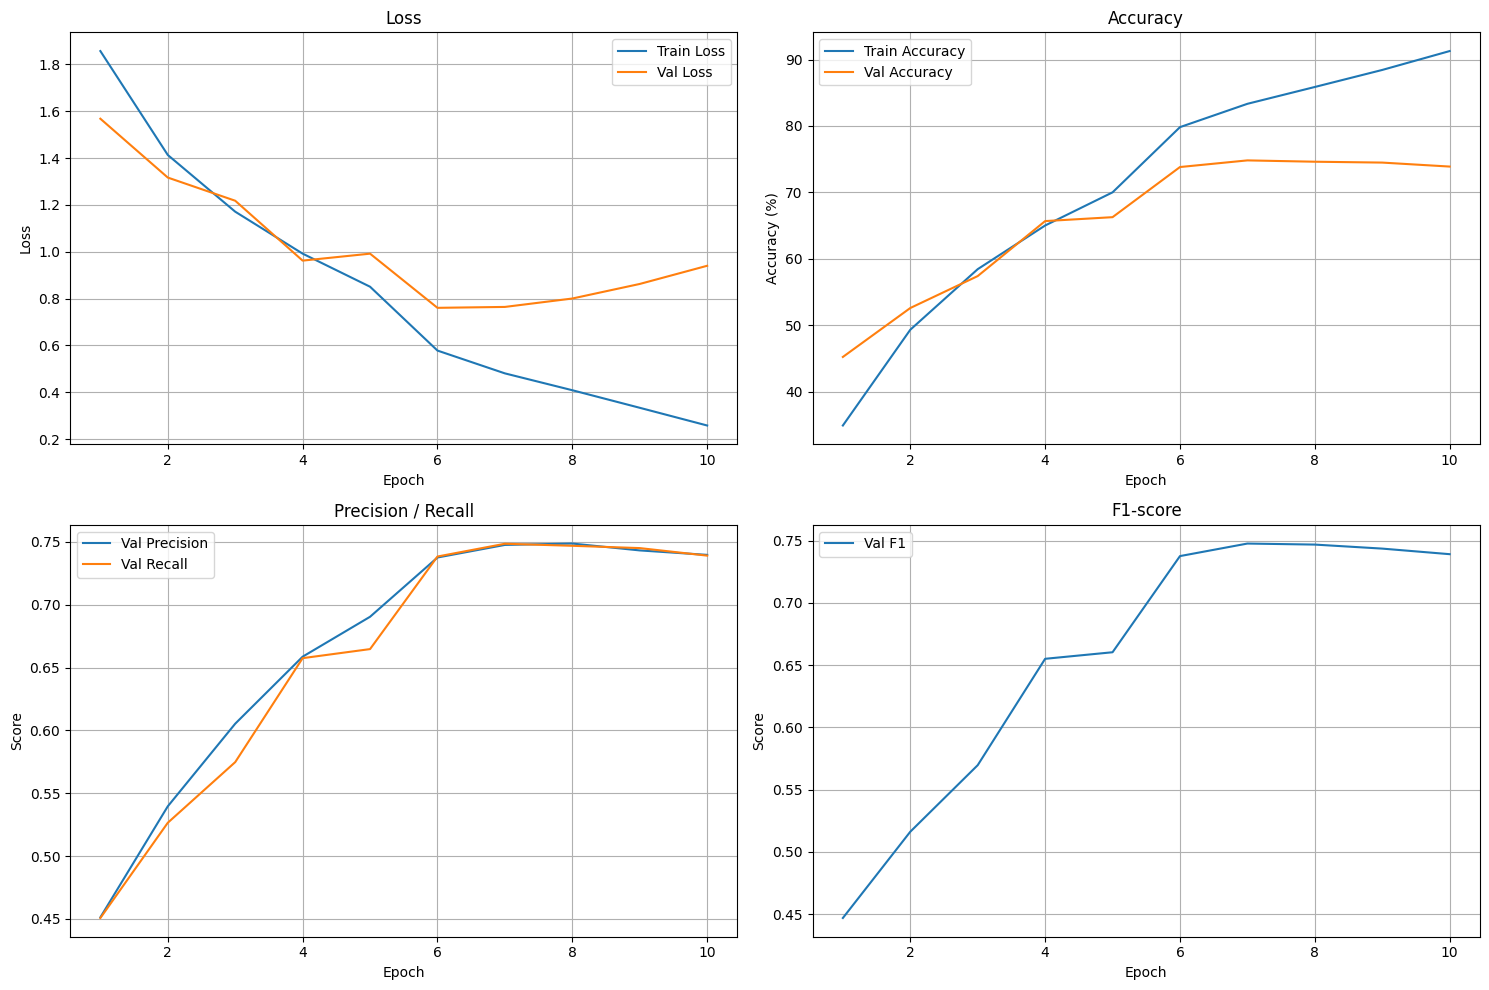

100%|██████████| 79/79 [00:03<00:00, 23.89it/s]

              precision    recall  f1-score   support

    airplane       0.77      0.75      0.76      1000
  automobile       0.84      0.83      0.83      1000
        bird       0.65      0.64      0.65      1000
         cat       0.53      0.55      0.54      1000
        deer       0.69      0.66      0.67      1000
         dog       0.61      0.63      0.62      1000
        frog       0.76      0.81      0.78      1000
       horse       0.80      0.77      0.79      1000
        ship       0.84      0.86      0.85      1000
       truck       0.80      0.78      0.79      1000

    accuracy                           0.73     10000
   macro avg       0.73      0.73      0.73     10000
weighted avg       0.73      0.73      0.73     10000

Test loss: 0.9763, test acc: 72.80%


In [28]:
trainer.run()

In [71]:
res_net_config2 = {
    'num_epochs': 30,
    'lr': 0.01,
    'batch_size': 128,
    'test_size': 0.2,
    'debug_batches': None,
}

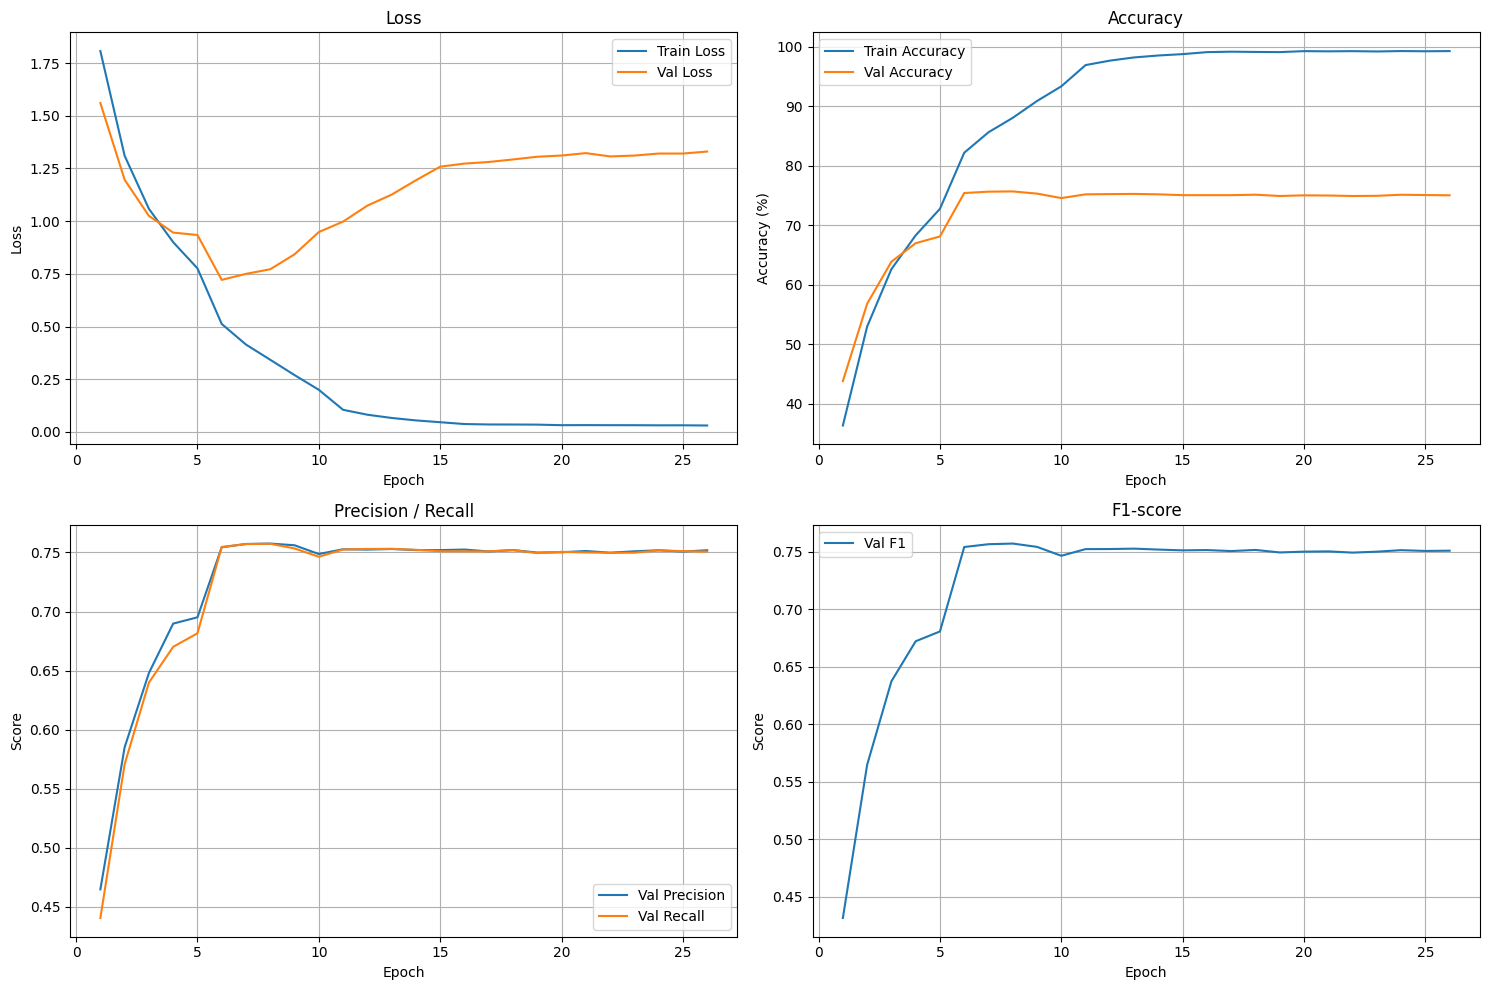

 70%|██████▉   | 218/313 [00:15<00:06, 14.09it/s]

In [ ]:
my_res_net = ResNet18()
trainer = Trainer(my_res_net, res_net_config2, transform=transform)
trainer.run()

!!! Кажется можо поставить побольше эпох, так как мы убрали проблему с прокидыванием градиентов, поставил 30, не знай сколько лучше, по графиикам увидим

Из моделей без скип коннекшена лучший резулльтат у той что с батч нормализацией и lr=0.001

In [ ]:
Стоит закончить обучение на 6-8 эпохе, после модель заучивает тренировку без улучшения обобщающей способности